# 2.2 $\quad$ Análisis del efecto de la diversificación en el riesgo de una cartera

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf


plt.style.use("ggplot")

## 1. Efecto de la diversificación en el riesgo de una cartera

Hemos visto que la varianza de una cartera de dos activos viene definida por:

$$\sigma^2_p= \underset{\text{Activo 1}} {\underbrace{w_1^2\sigma^2_1}}+\underset{\text{Activo 2}} {\underbrace{w_2^2\sigma^2_2}}+ \underset{\text{Relación entre activos}} {\underbrace{2w_1w_2 \sigma_{12}}}$$
       


Podemos generalizar para una cartera con $n$ activos:

$$\sigma^2_p = \underset{\text{Riesgo Activos}} {\underbrace{\sum_{i=1}^n w_i^2 \sigma_i^2}} + \underset{\text{Relación entre activos}} {\underbrace{ \sum_{i=1}^n \sum_{j=1}^n w_i w_j \sigma_{ij}}} \quad \forall i \neq j$$




Si hacemos una cartera en la que invertimos la misma cantidad en cada activo $\Rightarrow w_i = \dfrac{1}{n}$, la varianza de la cartera se puede escribir como:

$$\sigma_p^2= \dfrac{1}{n^2}\sum_{i=1}^{n} \sigma _i^2 + \dfrac{1}{n^2}\sum_{i=1}^{n}\sum_{j=1}^{n}\sigma_{ij} \quad \forall i \neq j$$

Llamando:

* Varianza media de los activos

$$\bar{V} = \dfrac{1}{n}\sum_{i=1}^{n} \sigma _i^2 \quad \Rightarrow \quad \sum_{i=1}^{n} \sigma _i^2 = n \bar{V}$$

* Covarianza media entre activos

$$\bar{\sigma_{ij}} = \dfrac{1}{n(n-1)}\sum_{i=1}^{n}\sum_{j=1}^{n}\sigma_{ij} \quad \Rightarrow \quad  \sum_{i=1}^{n}\sum_{j=1}^{n}\sigma_{ij} = n(n-1)\bar{\sigma_{ij}}$$

Sustituyendo en la ecuación de la varianza de una cartera equiponderada:

$$\sigma_p^2= \dfrac{1}{n^2}n \bar{V} + \dfrac{1}{n^2}n(n-1)\bar{\sigma_{ij}} = \dfrac{1}{n}\bar{V} + \left( 1 - \frac{1}{n}\right) \bar{\sigma_{ij}}$$

Si el número de activos $n$ tiende a infinito:

$$\lim_{n \to \infty} \sigma_p^2 =  \bar{\sigma_{ij}} $$

**Nos queda el riesgo sistémico o de mercado que no se puede eliminar con la diversificación**.

El riesgo sistémico es el riesgo que afecta a todos los activos de una cartera.

<center>
    <img src="https://github.com/bynak06-cell/microcredencial-carteras-python/blob/Feb-2025/Tema_2_Carteras_Intro/imgs/tipos_de_riesgos.PNG?raw=1"  alt="drawing" width="400">
</center>

## 2. Datos reales con S&P500

## EJERCICIO DE ANÁLISIS DEL EFECTO DE LA DIVERSIFICACIÓN:



**Objetivo:** El objetivo de este ejercicio es analizar cómo la volatilidad de una cartera de inversión varía a medida que se añaden diferentes activos a la misma

**Instrucciones:**

* **Descarga de Datos:**
Utiliza la lista de tickers tickers proporcionada para descargar los precios diarios de cierre ajustados de cada activo. Considera un rango de fechas específico para tu análisis.

* **Limpieza de Datos:**
Asegúrate de que todos los datos estén limpios y alineados por fecha. Elimina cualquier dato faltante.

* **Construcción de las Carteras:**
Inicia tu análisis con una cartera compuesta únicamente por los dos primeros activos de tu lista de tickers. Para estos dos activos, asigna pesos equiponderados y calcula la volatilidad de la cartera.
Posteriormente, diversifica gradualmente la cartera añadiendo un activo más de la lista en cada paso y calcula la volatilidad de cada cartera equiponderada.

* **Visualización:**

Crea un gráfico que muestre cómo la volatilidad de la cartera cambia a medida que se añaden más activos. El eje x debe representar el número de activos en la cartera, mientras que el eje y debe mostrar la volatilidad anualizada de la cartera.

In [3]:
tickers = [
    "A",
    "AAL",
    "AAP",
    "AAPL",
    "ABBV",
    "ABC",
    "ABT",
    "ACGL",
    "ACN",
    "ADBE",
    "ADI",
    "ADM",
    "ADP",
    "ADSK",
    "AEE",
    "AEP",
    "AES",
    "AFL",
    "AIG",
    "AIZ",
    "AJG",
    "AKAM",
    "ALB",
    "ALGN",
    "ALK",
    "ALL",
    "ALLE",
    "AMAT",
    "AMCR",
    "AMD",
    "AME",
    "AMGN",
    "AMP",
    "AMT",
    "AMZN",
    "ANET",
    "ANSS",
    "AON",
    "AOS",
    "APA",
    "APD",
    "APH",
    "APTV",
    "ARE",
    "ATO",
    "ATVI",
    "AVB",
    "AVGO",
    "AVY",
    "AWK",
    "AXON",
    "AXP",
    "AZO",
    "BA",
    "BAC",
    "BALL",
    "BAX",
    "BBWI",
    "BBY",
    "BDX",
    "BEN",
    "BG",
    "BIIB",
    "BIO",
    "BK",
    "BKNG",
    "BKR",
    "BLK",
    "BMY",
    "BR",
    "BRO",
    "BSX",
    "BWA",
    "BXP",
    "C",
    "CAG",
    "CAH",
    "CAT",
    "CB",
    "CBOE",
    "CBRE",
    "CCI",
    "CCL",
    "CDNS",
    "CDW",
    "CE",
    "CF",
    "CFG",
    "CHD",
    "CHRW",
    "CHTR",
    "CI",
    "CINF",
    "CL",
    "CLX",
    "CMA",
    "CMCSA",
    "CME",
    "CMG",
    "CMI",
    "CMS",
    "CNC",
    "CNP",
    "COF",
    "COO",
    "COP",
    "COST",
    "CPB",
    "CPRT",
    "CPT",
    "CRL",
    "CRM",
    "CSCO",
    "CSGP",
    "CSX",
    "CTAS",
    "CTLT",
    "CTRA",
    "CTSH",
    "CVS",
    "CVX",
    "CZR",
    "D",
    "DAL",
    "DD",
    "DE",
    "DFS",
    "DG",
    "DGX",
    "DHI",
    "DHR",
    "DIS",
    "DLR",
    "DLTR",
    "DOV",
    "DPZ",
    "DRI",
    "DTE",
    "DUK",
    "DVA",
    "DVN",
    "DXC",
    "DXCM",
    "EA",
    "EBAY",
    "ECL",
    "ED",
    "EFX",
    "EG",
    "EIX",
    "EL",
    "ELV",
    "EMN",
    "EMR",
    "ENPH",
    "EOG",
    "EPAM",
    "EQIX",
    "EQR",
    "EQT",
    "ES",
    "ESS",
    "ETN",
    "ETR",
    "ETSY",
    "EVRG",
    "EW",
    "EXC",
    "EXPD",
    "EXPE",
    "EXR",
    "F",
    "FANG",
    "FAST",
    "FCX",
    "FDS",
    "FDX",
    "FE",
    "FFIV",
    "FI",
    "FICO",
    "FIS",
    "FITB",
    "FLT",
    "FMC",
    "FRT",
    "FSLR",
    "FTNT",
    "GD",
    "GE",
    "GEN",
    "GILD",
    "GIS",
    "GL",
    "GLW",
    "GM",
    "GNRC",
    "GOOG",
    "GOOGL",
    "GPC",
    "GPN",
    "GRMN",
    "GS",
    "GWW",
    "HAL",
    "HAS",
    "HBAN",
    "HCA",
    "HD",
    "HES",
    "HIG",
    "HII",
    "HLT",
    "HOLX",
    "HON",
    "HPQ",
    "HRL",
    "HSIC",
    "HST",
    "HSY",
    "HUM",
    "IBM",
    "ICE",
    "IDXX",
    "IEX",
    "IFF",
    "ILMN",
    "INCY",
    "INTC",
    "INTU",
    "IP",
    "IPG",
    "IQV",
    "IRM",
    "ISRG",
    "IT",
    "ITW",
    "IVZ",
    "J",
    "JBHT",
    "JCI",
    "JKHY",
    "JNJ",
    "JNPR",
    "JPM",
    "K",
    "KDP",
    "KEY",
    "KEYS",
    "KHC",
    "KIM",
    "KLAC",
    "KMB",
    "KMI",
    "KMX",
    "KO",
    "KR",
    "L",
    "LDOS",
    "LEN",
    "LH",
    "LHX",
    "LIN",
    "LKQ",
    "LLY",
    "LMT",
    "LNC",
    "LNT",
    "LOW",
    "LRCX",
    "LUV",
    "LVS",
    "LYB",
    "LYV",
    "MA",
    "MAA",
    "MAR",
    "MAS",
    "MCD",
    "MCHP",
    "MCK",
    "MCO",
    "MDLZ",
    "MDT",
    "MET",
    "META",
    "MGM",
    "MHK",
    "MKC",
    "MKTX",
    "MLM",
    "MMC",
    "MMM",
    "MNST",
    "MO",
    "MOH",
    "MOS",
    "MPC",
    "MPWR",
    "MRK",
    "MRO",
    "MS",
    "MSCI",
    "MSFT",
    "MSI",
    "MTB",
    "MTCH",
    "MTD",
    "MU",
    "NCLH",
    "NDAQ",
    "NDSN",
    "NEE",
    "NEM",
    "NFLX",
    "NI",
    "NKE",
    "NOC",
    "NOW",
    "NRG",
    "NSC",
    "NTAP",
    "NTRS",
    "NUE",
    "NVDA",
    "NVR",
    "NWL",
    "NWS",
    "NWSA",
    "NXPI",
    "O",
    "ODFL",
    "OKE",
    "OMC",
    "ON",
    "ORCL",
    "ORLY",
    "OXY",
    "PANW",
    "PARA",
    "PAYC",
    "PAYX",
    "PCAR",
    "PCG",
    "PEAK",
    "PEG",
    "PEP",
    "PFE",
    "PFG",
    "PG",
    "PGR",
    "PH",
    "PHM",
    "PKG",
    "PLD",
    "PM",
    "PNC",
    "PNR",
    "PNW",
    "PODD",
    "POOL",
    "PPG",
    "PPL",
    "PRU",
    "PSA",
    "PSX",
    "PTC",
    "PWR",
    "PXD",
    "PYPL",
    "QCOM",
    "QRVO",
    "RCL",
    "REG",
    "REGN",
    "RF",
    "RHI",
    "RJF",
    "RL",
    "RMD",
    "ROK",
    "ROL",
    "ROP",
    "ROST",
    "RSG",
    "RTX",
    "RVTY",
    "SBAC",
    "SBUX",
    "SCHW",
    "SEDG",
    "SEE",
    "SHW",
    "SJM",
    "SLB",
    "SNA",
    "SNPS",
    "SO",
    "SPG",
    "SPGI",
    "SRE",
    "STE",
    "STLD",
    "STT",
    "STX",
    "STZ",
    "SWK",
    "SWKS",
    "SYF",
    "SYK",
    "SYY",
    "T",
    "TAP",
    "TDG",
    "TDY",
    "TECH",
    "TEL",
    "TER",
    "TFC",
    "TFX",
    "TGT",
    "TJX",
    "TMO",
    "TMUS",
    "TPR",
    "TRGP",
    "TRMB",
    "TROW",
    "TRV",
    "TSCO",
    "TSLA",
    "TSN",
    "TT",
    "TTWO",
    "TXN",
    "TXT",
    "TYL",
    "UAL",
    "UDR",
    "UHS",
    "ULTA",
    "UNH",
    "UNP",
    "UPS",
    "URI",
    "USB",
    "V",
    "VFC",
    "VLO",
    "VMC",
    "VRSK",
    "VRSN",
    "VRTX",
    "VTR",
    "VTRS",
    "VZ",
    "WAB",
    "WAT",
    "WBA",
    "WBD",
    "WDC",
    "WEC",
    "WELL",
    "WFC",
    "WHR",
    "WM",
    "WMB",
    "WMT",
    "WRB",
    "WRK",
    "WST",
    "WTW",
    "WY",
    "WYNN",
    "XEL",
    "XOM",
    "XRAY",
    "XYL",
    "YUM",
    "ZBH",
    "ZBRA",
    "ZION",
    "ZTS",
]

In [4]:
## TO-DO

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import missingno as msno

plt.style.use("ggplot")

data = yf.download(tickers, start = "2022-01-01", end = "2025-01-01", auto_adjust= False, multi_level_index= False)["Adj Close"]

[*********************100%***********************]  483 of 483 completed
ERROR:yfinance:
17 Failed downloads:
ERROR:yfinance:['MRO', 'WRK', 'FLT', 'CTLT', 'PARA', 'PEAK', 'ANSS', 'K', 'WBA', 'ATVI', 'JNPR', 'PXD', 'HES', 'IPG', 'DFS', 'FI', 'ABC']: YFTzMissingError('possibly delisted; no timezone found')


In [5]:
data

Ticker,A,AAL,AAP,AAPL,ABBV,ABC,ABT,ACGL,ACN,ADBE,...,WYNN,XEL,XOM,XRAY,XYL,YUM,ZBH,ZBRA,ZION,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2022-01-03,152.048309,18.750000,213.662949,178.103668,115.847221,NaN,128.345993,42.362530,383.711975,564.369995,...,85.125778,59.602112,54.760235,51.319401,110.957489,125.887207,121.125771,583.900024,55.144424,224.021255
2022-01-04,146.908142,19.020000,213.906570,175.843231,115.624809,NaN,125.327515,42.914051,380.969879,554.000000,...,84.854233,59.979332,56.820000,51.581013,112.134537,126.560318,122.354561,587.599976,56.715309,215.492279
2022-01-05,144.391464,18.680000,213.365158,171.165833,116.232170,NaN,124.764404,42.410072,374.260742,514.429993,...,81.711830,60.567108,57.526684,50.751083,110.606255,124.955971,121.951195,558.179993,56.844090,207.298370
2022-01-06,144.896698,18.570000,218.057465,168.308487,115.684677,NaN,124.745956,42.657307,356.187561,514.119995,...,82.090088,60.093376,58.879753,50.715004,110.454399,126.246834,120.938164,555.159973,59.178970,208.121567
2022-01-07,141.039169,19.280001,214.845032,168.474838,115.385269,NaN,125.133659,42.856995,349.355835,510.700012,...,82.002800,60.619747,59.362362,50.877384,109.571571,124.799194,120.206490,530.859985,60.166130,202.062286
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-24,134.764053,17.350000,42.505196,256.797211,172.530670,NaN,112.058289,92.669998,356.539642,447.940002,...,87.733513,65.511665,101.953667,17.868889,116.360298,131.828506,106.011848,395.440002,52.778500,161.848892
2024-12-26,134.496719,17.350000,43.000908,257.612732,171.763870,NaN,112.556282,92.930000,355.356506,450.160004,...,88.257263,65.482849,102.039902,18.114704,116.675453,132.805023,105.962448,396.850006,53.143349,162.654694
2024-12-27,134.209549,17.350000,42.825951,254.201385,170.623260,NaN,112.282875,92.339996,351.166351,446.480011,...,87.634682,65.444427,102.030319,18.057501,115.749687,132.053116,105.587006,389.070007,52.500065,161.750641


In [6]:
data = data.dropna(axis = 1 , how = "all")
data = data.dropna(axis = 0, how = "any")

<Axes: xlabel='Date'>

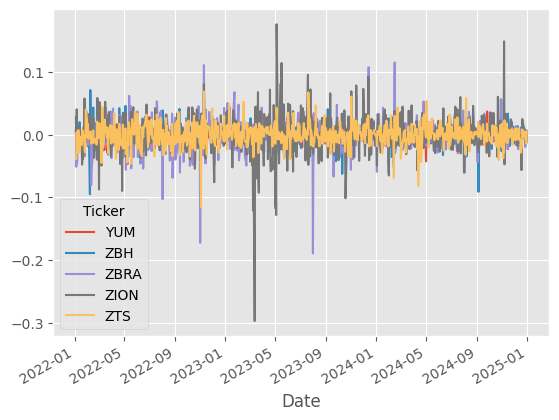

In [7]:
rets = np.log(data).diff().dropna()
rets.iloc[:,-5:].plot() # por ejemplo

In [8]:
for i in range(rets.shape[1]):
  print(i)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

In [9]:
for e in range(0,rets.shape[1],10):
  print(e)

0
10
20
30
40
50
60
70
80
90
100
110
120
130
140
150
160
170
180
190
200
210
220
230
240
250
260
270
280
290
300
310
320
330
340
350
360
370
380
390
400
410
420
430
440
450
460


In [10]:
rets.iloc[:,:4]

Ticker,A,AAL,AAP,AAPL
Date,,,,
2022-01-04,-0.034391,0.014297,0.001140,-0.012773
2022-01-05,-0.017279,-0.018038,-0.002534,-0.026960
2022-01-06,0.003493,-0.005906,0.021754,-0.016834
2022-01-07,-0.026983,0.037521,-0.014842,0.000988
2022-01-10,0.000069,-0.025743,-0.016772,0.000116
...,...,...,...,...
2024-12-24,0.011082,0.005780,-0.000457,0.011413
2024-12-26,-0.001986,0.000000,0.011595,0.003171
2024-12-27,-0.002137,0.000000,-0.004077,-0.013331


In [11]:

mean = []
std = []


for activo in range(2, rets.shape[1] ,1): # range(start= , stop= , step= )
  retornos = rets.iloc[:, :activo]
  pesos = np.ones(activo) / activo
  ret_cartera = retornos @ pesos
  # std_p = np.sqrt(pesos@ data.cov() @ pesos.T)
  std_p = ret_cartera.std()
  std.append(std_p)

  media = ret_cartera.mean()
  mean.append(media)







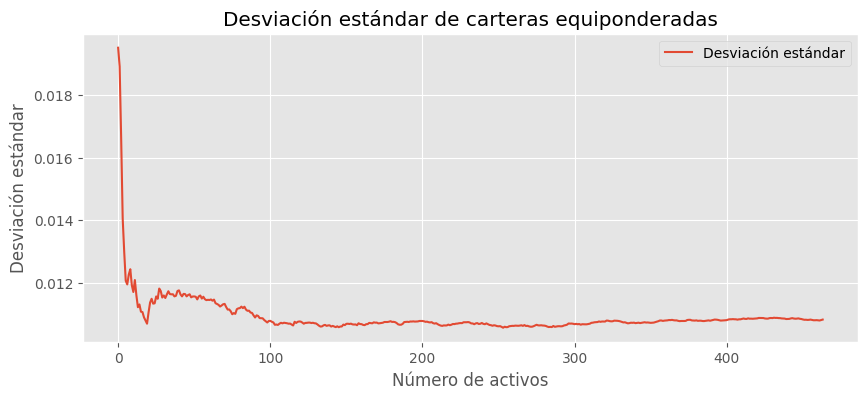

In [12]:
plt.figure(figsize=(10, 4))
plt.title("Desviación estándar de carteras equiponderadas")
plt.xlabel("Número de activos")
plt.ylabel("Desviación estándar")
plt.plot(std, label="Desviación estándar")


plt.legend()
plt.show()